## Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")
import matplotlib.gridspec as gridspec
from itertools import product
from scipy import stats
from datetime import date
import subprocess, sys
from io import BytesIO
for pkg in ["reportlab", "yfinance"]:
    try: __import__(pkg)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

try:
    import yfinance as yf
    HAS_YF = True
except ImportError:
    HAS_YF = False

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                 TableStyle, HRFlowable, PageBreak, Image)


import subprocess, sys
for pkg in ["reportlab", "yfinance"]:
    try: __import__(pkg)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

## PAIR TRading a partir d'ici , tests sur les pairs

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

CSV_PATH  = Path("continuous_series/ALL_continuous_OI_close.csv")
CONTRACTS = 100
TICKERS   = ["KC", "CC", "CT", "SB"]
NAMES     = {"CT": "Coton", "KC": "Café", "CC": "Cacao", "SB": "Sucre"}
COLORS    = {"CT": "#4A90D9", "KC": "#6F4E37", "CC": "#3D1C02", "SB": "#E8A838"}

WINDOWS   = [20, 30, 60]
ENTRY_ZS  = [1.5, 2.0, 2.5]
EXIT_ZS   = [0.0, 0.25, 0.5]
HEDGE_WIN = 252
HEDGE_MODE = "rolling"
ALL_PAIRS = list(combinations(TICKERS, 2))

df_all = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)

YF_SYMBOLS = {"KC": "KC=F", "CC": "CC=F", "CT": "CT=F", "SB": "SB=F"}

try:
    import yfinance as yf
    last_date = df_all.index[-1]
    today     = pd.Timestamp.today().normalize()
    if last_date < today - pd.Timedelta(days=1):
        recent = []
        for name, sym in YF_SYMBOLS.items():
            data = yf.download(sym, start=last_date.strftime("%Y-%m-%d"),
                               end=today.strftime("%Y-%m-%d"),
                               auto_adjust=True, progress=False)
            if not data.empty:
                s = data["Close"].squeeze().rename(name).dropna().sort_index()
                s = s[s.index > last_date]
                recent.append(s)
        if recent:
            df_recent = pd.concat(recent, axis=1)
            df_all    = pd.concat([df_all, df_recent]).sort_index()
            df_all    = df_all[~df_all.index.duplicated(keep="last")]
except Exception:
    pass


def test_coint(pxA, pxB):
    pair = pd.concat([pxA, pxB], axis=1).dropna()
    A, B = pair.iloc[:, 0], pair.iloc[:, 1]
    _, p_ab, _ = coint(A, B)
    _, p_ba, _ = coint(B, A)
    y_s, x_s, p = (A, B, p_ab) if p_ab <= p_ba else (B, A, p_ba)
    ols = sm.OLS(y_s, sm.add_constant(x_s)).fit()
    beta, alpha = ols.params.iloc[1], ols.params.iloc[0]
    return {
        "y": y_s.name, "x": x_s.name,
        "p_value": round(p, 4),
        "beta_static": round(beta, 4),
        "alpha_static": round(alpha, 4),
        "spread_static": y_s - (alpha + beta * x_s),
        "cointegrated": p <= 0.05,
    }


def rolling_ols(y, x, window=HEDGE_WIN):
    xs, ys = x.shift(1), y.shift(1)
    xm, ym = xs.rolling(window).mean(), ys.rolling(window).mean()
    betas = ((xs*ys).rolling(window).sum() - window*xm*ym) / \
            ((xs*xs).rolling(window).sum() - window*xm*xm + 1e-12)
    alphas = ym - betas * xm
    return alphas, betas


def half_life(spread):
    s = spread.dropna()
    ds = s.diff().dropna()
    sl = s.shift(1).dropna()
    b = np.linalg.lstsq(np.column_stack([sl.values, np.ones(len(sl))]), ds.values, rcond=None)[0]
    return round(-np.log(2) / b[0], 1) if b[0] < 0 else np.inf


def hurst(series, max_lag=100):
    s = series.dropna().values
    lags = range(2, min(max_lag, len(s) // 2))
    tau = [np.std(np.subtract(s[lag:], s[:-lag])) for lag in lags]
    return round(np.polyfit(np.log(lags), np.log(tau), 1)[0], 3)


def run_pairs(pxA, pxB, window_z, entry_z, exit_z, ci):
    pair = pd.concat([pxA, pxB], axis=1).dropna()
    y_s, x_s = pair[ci["y"]], pair[ci["x"]]

    if HEDGE_MODE == "rolling":
        alpha_s, beta_s = rolling_ols(y_s, x_s)
    else:
        alpha_s = pd.Series(ci["alpha_static"], index=y_s.index)
        beta_s  = pd.Series(ci["beta_static"],  index=y_s.index)

    spread = y_s - (alpha_s + beta_s * x_s)
    z = (spread - spread.rolling(window_z).mean()) / (spread.rolling(window_z).std() + 1e-12)

    valid = z.dropna().index
    pos, state = pd.Series(0.0, index=z.index), 0
    for i in range(1, len(z)):
        if z.index[i] not in valid or z.index[i-1] not in valid:
            continue
        if state == 0:
            if z.iloc[i-1] < -entry_z:
                state = 1
            elif z.iloc[i-1] > entry_z:
                state = -1
        elif abs(z.iloc[i-1]) < exit_z:
            state = 0
        pos.iloc[i] = state

    daily = (pos * CONTRACTS * y_s.diff() - pos * beta_s * CONTRACTS * x_s.diff()).fillna(0)
    cumul = daily.cumsum()
    n_y   = len(daily) / 252
    vol   = daily.std() * np.sqrt(252)
    dd    = cumul - cumul.cummax()
    total = cumul.iloc[-1]
    sharpe = (daily.mean() * 252) / (vol + 1e-12)
    max_dd = dd.min()
    runs  = (pos != 0).astype(int)
    tlens = runs[runs == 1].groupby(((runs != runs.shift()).cumsum())[runs == 1]).count()

    return {
        "cumul": cumul, "daily": daily, "dd": dd,
        "z": z, "spread": spread, "pos": pos,
        "alpha": alpha_s, "beta": beta_s,
        "total": total, "ann": total / n_y,
        "sharpe": sharpe, "max_dd": max_dd,
        "calmar": (total / n_y) / abs(max_dd) if max_dd != 0 else 0,
        "n_trades": int((pos.diff().abs() > 0.5).sum()),
        "avg_dur": round(tlens.mean(), 1) if len(tlens) > 0 else 0,
        "n_years": n_y,
    }


def grid_search():
    n_combos = len(ALL_PAIRS) * len(WINDOWS) * len(ENTRY_ZS) * len(EXIT_ZS)
    print(f"\n  {n_combos} combinaisons à tester ({len(ALL_PAIRS)} paires)...\n")
    print("  Tests de coïntégration Engle-Granger :")

    coint_cache = {}
    for A, B in ALL_PAIRS:
        ci = test_coint(df_all[A].dropna(), df_all[B].dropna())
        coint_cache[(A, B)] = ci
        hl = half_life(ci["spread_static"])
        hu = hurst(ci["spread_static"])
        flag = "OK" if ci["cointegrated"] else "XX"
        print(f"  {A}/{B}  | p={ci['p_value']:.4f} {flag} | "
              f"β={ci['beta_static']:8.3f} | HL={hl:6.1f}j | Hurst={hu:.3f} | dir={ci['y']}~{ci['x']}")

    results = []
    for A, B in ALL_PAIRS:
        ci = coint_cache[(A, B)]
        hl = half_life(ci["spread_static"])
        hu = hurst(ci["spread_static"])
        for wz in WINDOWS:
            for ez in ENTRY_ZS:
                for xz in EXIT_ZS:
                    if xz >= ez:
                        continue
                    try:
                        res = run_pairs(df_all[A].dropna(), df_all[B].dropna(), wz, ez, xz, ci)
                        if res["n_trades"] < 5:
                            continue
                        results.append({
                            "pair": f"{A}/{B}", "y": ci["y"], "x": ci["x"],
                            "p_value": ci["p_value"], "cointegrated": ci["cointegrated"],
                            "beta": round(ci["beta_static"], 4),
                            "half_life": hl, "hurst": hu,
                            "window_z": wz, "entry_z": ez, "exit_z": xz,
                            "total_pnl": round(res["total"], 0),
                            "ann_pnl": round(res["ann"], 0),
                            "sharpe": round(res["sharpe"], 2),
                            "max_dd": round(res["max_dd"], 0),
                            "calmar": round(res["calmar"], 2),
                            "n_trades": res["n_trades"],
                            "avg_dur": res["avg_dur"],
                        })
                    except Exception:
                        continue

    df_r = pd.DataFrame(results)
    if df_r.empty:
        return df_r

    df_r["score"] = (
        df_r["sharpe"].rank(pct=True)    * 0.35 +
        df_r["calmar"].rank(pct=True)    * 0.30 +
        df_r["total_pnl"].rank(pct=True) * 0.20 +
        (1 - df_r["p_value"]).clip(0, 1).rank(pct=True) * 0.15
    )
    return df_r.sort_values("score", ascending=False).reset_index(drop=True)


print("=" * 65)
print("  PAIRS TRADING — Engle-Granger + OLS Rolling Hedge Ratio")
print("=" * 65)

df_grid = grid_search()

if not df_grid.empty:
    df_grid.to_csv(Path("continuous_series") / "EG_pairs_grid_results.csv", index=False)

    cols = ["pair","y","x","p_value","cointegrated","beta","half_life","hurst",
            "window_z","entry_z","exit_z","total_pnl","sharpe","max_dd","calmar","n_trades","avg_dur","score"]
    print("\n  TOP 10 :")
    print(df_grid[cols].head(10).to_string())

    best = df_grid.groupby("pair").first().reset_index().sort_values("score", ascending=False)
    print("\n  Meilleure config par paire :")
    print(best[["pair","p_value","cointegrated","half_life","hurst","total_pnl","sharpe","max_dd","calmar","n_trades","score"]].to_string())

  PAIRS TRADING — Engle-Granger + OLS Rolling Hedge Ratio

  162 combinaisons à tester (6 paires)...

  Tests de coïntégration Engle-Granger :
  KC/CC  | p=0.0090 OK | β=  18.017 | HL= 169.0j | Hurst=0.469 | dir=CC~KC
  KC/CT  | p=0.0029 OK | β=   0.154 | HL= 216.2j | Hurst=0.527 | dir=CT~KC
  KC/SB  | p=0.0204 OK | β=   0.052 | HL= 259.7j | Hurst=0.513 | dir=SB~KC
  CC/CT  | p=0.0112 OK | β=   0.002 | HL= 286.0j | Hurst=0.545 | dir=CT~CC
  CC/SB  | p=0.0306 OK | β=   0.002 | HL= 304.5j | Hurst=0.519 | dir=SB~CC
  CT/SB  | p=0.0002 OK | β=   2.350 | HL= 163.5j | Hurst=0.532 | dir=CT~SB

  TOP 10 :
    pair   y   x  p_value  cointegrated     beta  half_life  hurst  window_z  entry_z  exit_z  total_pnl  sharpe    max_dd  calmar  n_trades  avg_dur     score
0  CC/CT  CT  CC   0.0112          True   0.0022      286.0  0.545        60      2.0    0.25    19438.0    0.29   -5662.0    0.10       277     28.3  0.895139
1  CC/CT  CT  CC   0.0112          True   0.0022      286.0  0.545        3

In [3]:
A, B  = "CC", "CT"
NAMES = {"CT": "Coton", "CC": "Cacao"}

WINDOWS_Z    = [15, 20, 30, 45, 60, 90, 120]
ENTRY_ZS     = [1.0, 1.5, 2.0, 2.5, 3.0]
EXIT_ZS      = [0.0, 0.25, 0.5, 0.75]
HEDGE_WINS   = [126, 252, 504]
STOP_LOSS_ZS = [None, 3.0, 4.0, 5.0]

pxCC_ = df_all["CC"].dropna().sort_index()
pxCT_ = df_all["CT"].dropna().sort_index()
pair  = pd.concat([pxCC_, pxCT_], axis=1).dropna()
pxCC_ = pair["CC"]
pxCT_ = pair["CT"]


def precompute_rolling_ols(y, x, window):
    xs, ys = x.shift(1), y.shift(1)
    xm, ym = xs.rolling(window).mean(), ys.rolling(window).mean()
    betas = ((xs*ys).rolling(window).sum() - window*xm*ym) / \
            ((xs*xs).rolling(window).sum() - window*xm*xm + 1e-12)
    alphas = ym - betas * xm
    return alphas, betas


ols_cache = {}
for hw in HEDGE_WINS:
    ols_cache[hw] = precompute_rolling_ols(pxCT_, pxCC_, hw)


def backtest(alpha_s, beta_s, window_z, entry_z, exit_z, sl_z=None):
    spread = pxCT_ - (alpha_s + beta_s * pxCC_)
    z = (spread - spread.rolling(window_z).mean()) / (spread.rolling(window_z).std() + 1e-12)
    valid = ~(z.isna() | alpha_s.isna() | beta_s.isna())

    pos, state = np.zeros(len(z)), 0
    z_arr, v_arr = z.values, valid.values
    for i in range(1, len(z)):
        if not v_arr[i]:
            continue
        zi = z_arr[i-1]
        if state == 0:
            if zi < -entry_z:
                state = 1
            elif zi > entry_z:
                state = -1
        else:
            if abs(zi) < exit_z or (sl_z is not None and abs(zi) > sl_z):
                state = 0
        pos[i] = state

    pos_s = pd.Series(pos, index=z.index)
    daily = ((pos_s * pxCT_.diff()) - (pos_s * beta_s.reindex(z.index) * pxCC_.diff())) * CONTRACTS
    daily = daily.fillna(0)
    cumul = daily.cumsum()
    n_y   = len(daily) / 252
    total = cumul.iloc[-1]
    vol   = daily.std() * np.sqrt(252)
    dd    = cumul - cumul.cummax()
    sharpe = (daily.mean() * 252) / (vol + 1e-12)
    max_dd = dd.min()
    calmar = (total / n_y) / abs(max_dd) if max_dd != 0 else 0
    n_tr  = int((pos_s.diff().abs() > 0.5).sum())
    pos_pnl, neg_pnl = daily[daily > 0].sum(), daily[daily < 0].sum()
    pf    = abs(pos_pnl / neg_pnl) if neg_pnl != 0 else np.inf
    runs  = (pos_s != 0).astype(int)
    tlens = runs[runs == 1].groupby(((runs != runs.shift()).cumsum())[runs == 1]).count()

    return {
        "cumul": cumul, "daily": daily, "dd": dd,
        "z": z, "spread": spread, "pos": pos_s,
        "total": total, "ann": total / n_y,
        "sharpe": sharpe, "max_dd": max_dd,
        "calmar": calmar, "pf": pf,
        "n_trades": n_tr,
        "avg_dur": tlens.mean() if len(tlens) > 0 else 0,
        "pct_in": (pos_s != 0).mean() * 100,
    }


def grid_search():
    combos = [(hw, wz, ez, xz, sl)
              for hw, wz, ez, xz, sl in product(HEDGE_WINS, WINDOWS_Z, ENTRY_ZS, EXIT_ZS, STOP_LOSS_ZS)
              if xz < ez and (sl is None or sl > ez)]

    results = []
    for hw, wz, ez, xz, sl in combos:
        try:
            res = backtest(*ols_cache[hw], wz, ez, xz, sl)
            if res["n_trades"] < 5:
                continue
            results.append({
                "hedge_win": hw, "window_z": wz, "entry_z": ez, "exit_z": xz,
                "stop_z": sl if sl else 0,
                "total_pnl": round(res["total"], 0),
                "ann_pnl": round(res["ann"], 0),
                "sharpe": round(res["sharpe"], 3),
                "max_dd": round(res["max_dd"], 0),
                "calmar": round(res["calmar"], 3),
                "pf": round(res["pf"], 2),
                "n_trades": res["n_trades"],
                "avg_dur": round(res["avg_dur"], 1),
                "pct_in": round(res["pct_in"], 1),
            })
        except Exception:
            continue

    df = pd.DataFrame(results)
    if df.empty:
        return df
    df["score"] = (
        df["sharpe"].rank(pct=True)    * 0.35 +
        df["calmar"].rank(pct=True)    * 0.30 +
        df["pf"].rank(pct=True)        * 0.20 +
        df["total_pnl"].rank(pct=True) * 0.15
    )
    return df.sort_values("score", ascending=False).reset_index(drop=True)


def walk_forward(hw, wz, ez, xz, sl):
    split = int(len(pair) * 0.70)
    a_tr, b_tr = precompute_rolling_ols(pxCT_.iloc[:split], pxCC_.iloc[:split], hw)
    a_full = a_tr.reindex(pxCT_.index).ffill()
    b_full = b_tr.reindex(pxCT_.index).ffill()
    res_train = backtest(a_tr, b_tr, wz, ez, xz, sl)
    res_test  = backtest(a_full.iloc[split:], b_full.iloc[split:], wz, ez, xz, sl)
    eff = (res_test["total"] / res_train["total"] * 100) if res_train["total"] != 0 else 0
    if eff > 30:
        verdict = "ROBUSTE"
    elif eff > 0:
        verdict = "FRAGILE"
    else:
        verdict = "OVERFITTE"
    return {
        "train": res_train, "test": res_test,
        "split_date": pair.index[split],
        "efficiency": eff,
        "verdict": verdict,
    }


df_grid = grid_search()

if not df_grid.empty:
    df_grid.to_csv(Path("continuous_series") / "CC_CT_grid_search.csv", index=False)
    cols = ["hedge_win","window_z","entry_z","exit_z","stop_z","total_pnl","sharpe","max_dd","calmar","pf","n_trades","avg_dur","score"]
    print(f"\n{'='*75}\n  CC/CT — TOP 15 configurations\n{'='*75}")
    print(df_grid[cols].head(15).to_string())


  CC/CT — TOP 15 configurations
    hedge_win  window_z  entry_z  exit_z  stop_z  total_pnl  sharpe   max_dd  calmar    pf  n_trades  avg_dur     score
0         504        20      1.0    0.25     5.0    43613.0   0.567  -6017.0   0.218  1.14       875     13.8  0.994838
1         504        20      1.0    0.25     4.0    43613.0   0.567  -6017.0   0.218  1.14       875     13.8  0.994838
2         504        20      1.0    0.25     0.0    43613.0   0.567  -6017.0   0.218  1.14       875     13.8  0.994838
3         504        20      1.0    0.25     3.0    41100.0   0.535  -5796.0   0.214  1.13       921     13.1  0.991077
4         504        15      1.0    0.75     3.0    36891.0   0.530 -10089.0   0.110  1.15      1787      5.2  0.990192
5         504        15      1.0    0.75     0.0    36195.0   0.520 -10089.0   0.108  1.15      1769      5.3  0.988901
6         504        15      1.0    0.75     5.0    36195.0   0.520 -10089.0   0.108  1.15      1769      5.3  0.988901
7      

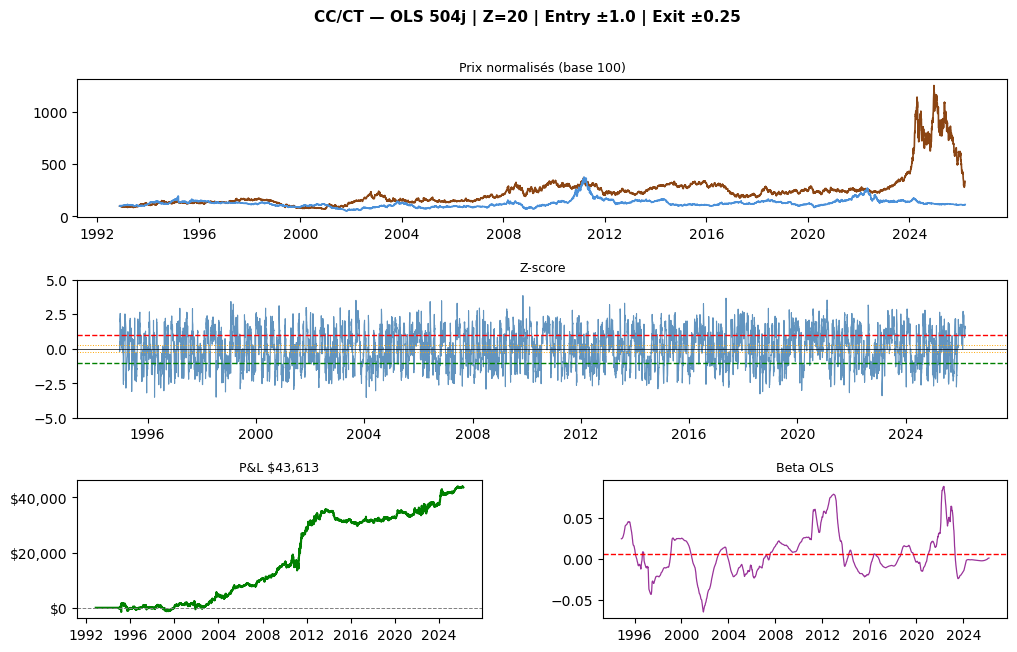

In [8]:
HEDGE_WIN = 504
WINDOW_Z  = 20
ENTRY_Z   = 1.0
EXIT_Z    = 0.25

alpha_s, beta_s = ols_cache[HEDGE_WIN]

spread = pxCT_ - (alpha_s + beta_s * pxCC_)
z = (spread - spread.rolling(WINDOW_Z).mean()) / (spread.rolling(WINDOW_Z).std() + 1e-12)

pos, state, z_arr = np.zeros(len(z)), 0, z.values
for i in range(1, len(z)):
    if np.isnan(z_arr[i-1]):
        continue
    if state == 0:
        if z_arr[i-1] < -ENTRY_Z:
            state = 1
        elif z_arr[i-1] > ENTRY_Z:
            state = -1
    elif abs(z_arr[i-1]) < EXIT_Z:
        state = 0
    pos[i] = state

pos_s = pd.Series(pos, index=pxCT_.index)
daily = (pos_s * pxCT_.diff() - pos_s * beta_s * pxCC_.diff()) * CONTRACTS
daily = daily.fillna(0)
cumul = daily.cumsum()
dd    = cumul - cumul.cummax()

n_years  = len(daily) / 252
total    = cumul.iloc[-1]
vol      = daily.std() * np.sqrt(252)
sharpe   = (daily.mean() * 252) / (vol + 1e-12)
max_dd   = dd.min()
calmar   = (total / n_years) / abs(max_dd) if max_dd != 0 else 0
n_trades = int((pos_s.diff().abs() > 0.5).sum())
pf       = abs(daily[daily > 0].sum() / daily[daily < 0].sum()) if daily[daily < 0].sum() != 0 else np.inf
pct_in   = (pos_s != 0).mean() * 100
runs     = (pos_s != 0).astype(int)
tlens    = runs[runs == 1].groupby(((runs != runs.shift()).cumsum())[runs == 1]).count()
avg_dur  = tlens.mean() if len(tlens) > 0 else 0

fig = plt.figure(figsize=(12, 7))
fig.suptitle(
    f"CC/CT — OLS {HEDGE_WIN}j | Z={WINDOW_Z} | Entry ±{ENTRY_Z} | Exit ±{EXIT_Z}",
    fontsize=11, fontweight="bold"
)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)
fmt_year = plt.matplotlib.dates.DateFormatter("%Y")
fmt_dollar = plt.FuncFormatter(lambda x, _: f"${x:,.0f}")

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pxCC_ / pxCC_.iloc[0] * 100, lw=1.2, color="#8B4513", label="Cacao")
ax1.plot(pxCT_ / pxCT_.iloc[0] * 100, lw=1.2, color="#4A90D9", label="Coton")
ax1.set_title("Prix normalisés (base 100)", fontsize=9)
ax1.xaxis.set_major_formatter(fmt_year)

ax2 = fig.add_subplot(gs[1, :])
ax2.plot(z.index, z.values, lw=0.8, color="steelblue", alpha=0.85)
ax2.axhline( ENTRY_Z, color="red",    lw=1, linestyle="--")
ax2.axhline(-ENTRY_Z, color="green",  lw=1, linestyle="--")
ax2.axhline( EXIT_Z,  color="orange", lw=0.7, linestyle=":")
ax2.axhline(-EXIT_Z,  color="orange", lw=0.7, linestyle=":")
ax2.axhline(0, color="black", lw=0.5)
ax2.set_title(f"Z-score", fontsize=9)
ax2.set_ylim(-5, 5)
ax2.xaxis.set_major_formatter(fmt_year)

ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(cumul.index, cumul.values, lw=1.5, color="green")
ax3.axhline(0, lw=0.7, color="grey", linestyle="--")
ax3.set_title(f"P&L ${total:,.0f}", fontsize=9)
ax3.yaxis.set_major_formatter(fmt_dollar)
ax3.xaxis.set_major_formatter(fmt_year)

ax4 = fig.add_subplot(gs[2, 1])
ax4.plot(beta_s.index, beta_s.values, lw=0.9, color="purple", alpha=0.8)
ax4.axhline(beta_s.mean(), color="red", lw=1, linestyle="--")
ax4.set_title(f"Beta OLS", fontsize=9)
ax4.xaxis.set_major_formatter(fmt_year)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### SAISONNALITE

  BREAKOUT + FILTRE SAISONNIER — Comparaison baseline
  Critère : p<0.1 + stabilité>55%
  Logique : Long filtré / Short bloqué sur bons mois

  Café (KC)...

  Café (KC)

  Mois Long autorisés (fréquence sur 35 ans) :
    Nov  :  97.1% ███████████████████
    Jan  :  82.9% ████████████████
    Fév  :  80.0% ████████████████
    Avr  :  80.0% ████████████████
    Aoû  :  80.0% ████████████████
    Déc  :  80.0% ████████████████

  Métrique                 Baseline       Filtré      Delta
  --------------------------------------------------------
  P&L Total                 $72,985      $62,856   $-10,128
  Sharpe                       0.67         0.63      -0.04
  Profit Factor                1.72         1.73      +0.02
  Max Drawdown              $-5,512      $-4,693      $+819
  Calmar                       0.40         0.41      +0.00
  Winrate                     45.6%        44.9%      -0.7%
  Nb Trades                     500          437        -63
  Signaux filtrés            

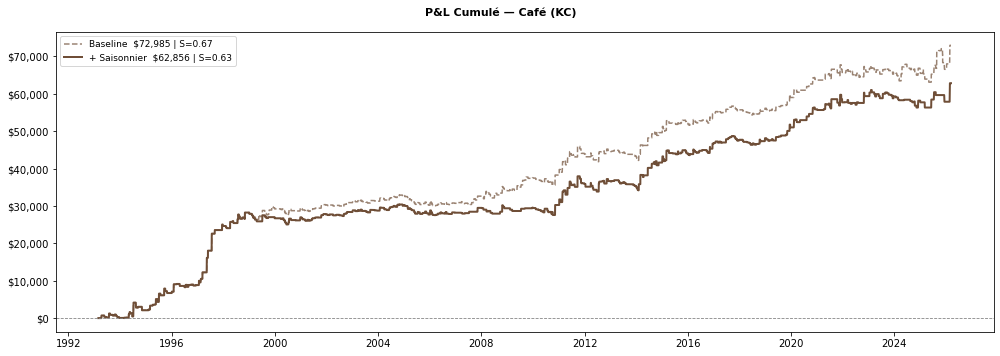


  Cacao (CC)...

  Cacao (CC)

  Mois Long autorisés (fréquence sur 35 ans) :
    Jan  :  77.1% ███████████████
    Avr  :  77.1% ███████████████
    Jun  :  77.1% ███████████████
    Nov  :  77.1% ███████████████
    Fév  :  74.3% ██████████████
    Aoû  :  71.4% ██████████████

  Métrique                 Baseline       Filtré      Delta
  --------------------------------------------------------
  P&L Total                $683,829     $282,946  $-400,882
  Sharpe                       0.39         0.34      -0.06
  Profit Factor                4.41         3.29      -1.12
  Max Drawdown             $-47,711     $-20,929   $+26,782
  Calmar                       0.43         0.41      -0.02
  Winrate                     48.6%        46.7%      -2.0%
  Nb Trades                      74           60        -14
  Signaux filtrés                 —     L:19 S:2           


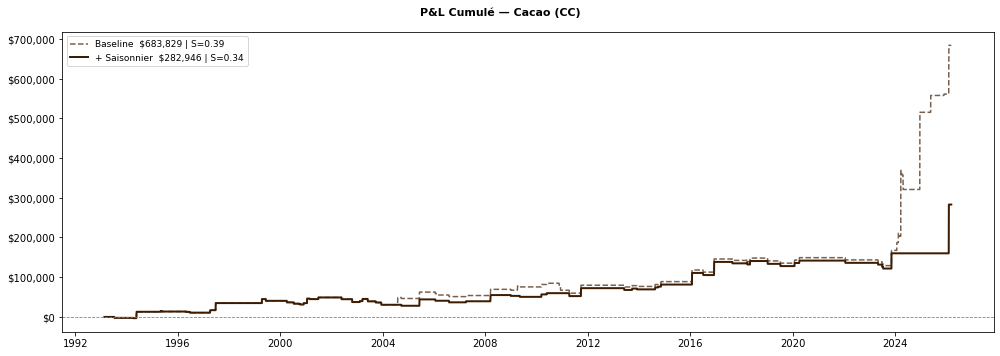


  Coton (CT)...

  Coton (CT)

  Mois Long autorisés (fréquence sur 35 ans) :
    Déc  :  68.6% █████████████
    Jan  :  62.9% ████████████
    Fév  :  57.1% ███████████
    Nov  :  54.3% ██████████
    Avr  :  48.6% █████████
    Jun  :  48.6% █████████

  Métrique                 Baseline       Filtré      Delta
  --------------------------------------------------------
  P&L Total                 $31,331      $16,841   $-14,490
  Sharpe                       0.68         0.44      -0.24
  Profit Factor                2.39         1.94      -0.45
  Max Drawdown              $-1,463      $-1,426       $+37
  Calmar                       0.65         0.36      -0.29
  Winrate                     45.6%        44.4%      -1.1%
  Nb Trades                     261          189        -72
  Signaux filtrés                 —    L:120 S:7           


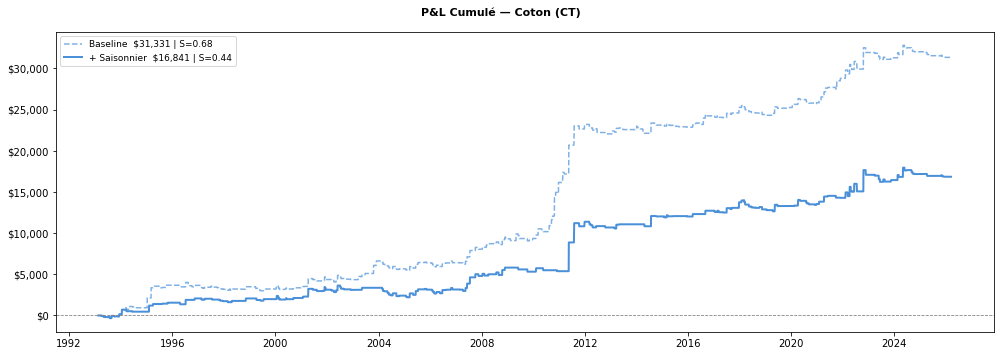


  Sucre (SB)...

  Sucre (SB)

  Mois Long autorisés (fréquence sur 35 ans) :
    Jun  :  62.9% ████████████
    Jul  :  54.3% ██████████
    Sep  :  48.6% █████████
    Jan  :  45.7% █████████
    Nov  :  42.9% ████████
    Fév  :  40.0% ████████

  Métrique                 Baseline       Filtré      Delta
  --------------------------------------------------------
  P&L Total                  $6,404       $4,262    $-2,141
  Sharpe                       0.64         0.54      -0.10
  Profit Factor                2.04         2.09      +0.05
  Max Drawdown                $-379        $-368       $+11
  Calmar                       0.51         0.35      -0.16
  Winrate                     46.2%        46.6%      +0.4%
  Nb Trades                     299          204        -95
  Signaux filtrés                 —   L:118 S:13           


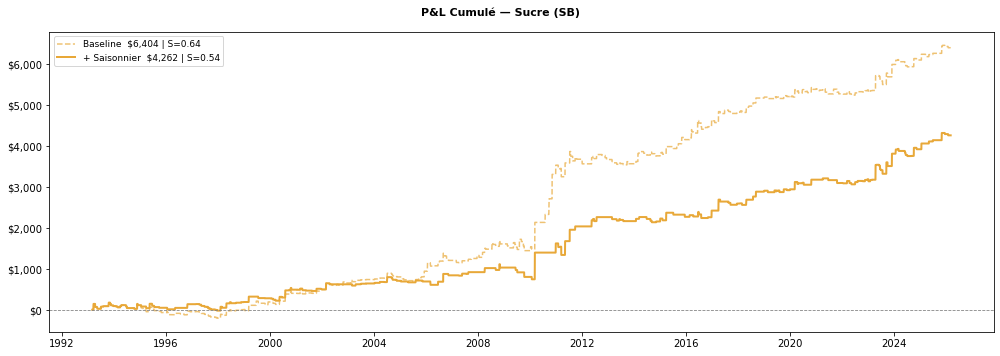

In [5]:
NAMES = {"CT": "Coton", "KC": "Café", "CC": "Cacao", "SB": "Sucre"}
MOIS  = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]

PVAL_THRESH  = 0.10
STAB_THRESH  = 0.55
LOOKBACK_YRS = 5

BREAKOUT_PARAMS = {
    "CT": {"bb_period":15,"bb_std":1.5,"atr_period":14,"atr_expansion":1.00,"sl_atr":2.5,"chandelier_atr":3.0,"tp_atr":10.0,"use_ema_filter":False},
    "KC": {"bb_period":15,"bb_std":1.5,"atr_period":20,"atr_expansion":0.80,"sl_atr":2.0,"chandelier_atr":2.5,"tp_atr":8.0,"use_ema_filter":False},
    "CC": {"bb_period":15,"bb_std":2.0,"atr_period":14,"atr_expansion":1.20,"sl_atr":1.5,"chandelier_atr":2.5,"tp_atr":8.0,"ema_filter":100,"use_ema_filter":True},
    "SB": {"bb_period":15,"bb_std":2.0,"atr_period":20,"atr_expansion":0.80,"sl_atr":2.0,"chandelier_atr":3.0,"tp_atr":10.0,"use_ema_filter":False},
}


def compute_seasonal_filter(prices, lookback=LOOKBACK_YRS):
    ret     = prices.pct_change().dropna()
    years   = sorted(ret.index.year.unique())
    filters = {}
    for year in years:
        train = ret[(ret.index.year >= year - lookback) & (ret.index.year < year)]
        if len(train) < 200:
            filters[year] = {"long_ok": set(range(1, 13)), "short_blocked": set()}
            continue
        long_ok, short_blocked = set(), set()
        for m in range(1, 13):
            vals = train[train.index.month == m].dropna()
            if len(vals) < 10:
                continue
            mean_ret = vals.mean()
            _, pvalue = stats.ttest_1samp(vals, 0)
            stab = (vals.resample("A").sum() > 0).mean()
            if mean_ret > 0 and pvalue < PVAL_THRESH and stab > STAB_THRESH:
                long_ok.add(m)
                short_blocked.add(m)
        filters[year] = {"long_ok": long_ok if long_ok else set(range(1, 13)), "short_blocked": short_blocked}
    return filters, ret


def get_filter_for_date(date, filters):
    return filters.get(date.year, {"long_ok": set(range(1, 13)), "short_blocked": set()}).values()


def compute_breakout_indicators(prices, p):
    df = pd.DataFrame({"close": prices})
    if p.get("use_ema_filter") and "ema_filter" in p:
        df["ema"] = df["close"].ewm(span=int(p["ema_filter"]), adjust=False).mean()
    df["bb_mid"]   = df["close"].rolling(int(p["bb_period"])).mean()
    bbs            = df["close"].rolling(int(p["bb_period"])).std()
    df["bb_upper"] = df["bb_mid"] + p["bb_std"] * bbs
    df["bb_lower"] = df["bb_mid"] - p["bb_std"] * bbs
    prev           = df["close"].shift(1)
    tr             = pd.concat([(df["close"]-prev).abs(), df["close"].diff().abs()], axis=1).max(axis=1)
    df["atr"]      = tr.rolling(int(p["atr_period"])).mean()
    df["atr_mean"] = df["atr"].rolling(50).mean()
    df["high_r"]   = df["close"].rolling(int(p["atr_period"])).max()
    df["low_r"]    = df["close"].rolling(int(p["atr_period"])).min()
    df["ch_long"]  = df["high_r"] - p["chandelier_atr"] * df["atr"]
    df["ch_short"] = df["low_r"]  + p["chandelier_atr"] * df["atr"]
    df["bu"]       = (df["close"] > df["bb_upper"]) & (df["close"].shift(1) <= df["bb_upper"].shift(1))
    df["bd"]       = (df["close"] < df["bb_lower"]) & (df["close"].shift(1) >= df["bb_lower"].shift(1))
    if p.get("use_ema_filter") and "ema_filter" in p:
        df["above_ema"] = df["close"] > df["ema"]
        df["below_ema"] = df["close"] < df["ema"]
    return df.dropna()


def _run_loop(prices, params, filters=None):
    df       = compute_breakout_indicators(prices, params)
    position = None
    pnl_d, trades = {}, []
    cumul, last_sl = 0.0, None
    filtered_long = filtered_short = 0

    for date, row in df.iterrows():
        price, atr = row["close"], row["atr"]

        if position is not None:
            side = position["side"]
            d    = 1 if side == "long" else -1
            position["trail"] = max(position["trail"], row["ch_long"]) if side == "long" else min(position["trail"], row["ch_short"])
            tp_hit = (side=="long" and price >= position["tp"]) or (side=="short" and price <= position["tp"])
            tr_hit = (side=="long" and price <= position["trail"]) or (side=="short" and price >= position["trail"])
            sl_hit = (side=="long" and price <= position["sl"])   or (side=="short" and price >= position["sl"])
            if tp_hit or tr_hit or sl_hit:
                ex     = position["tp"] if tp_hit else (position["trail"] if tr_hit else position["sl"])
                pnl_tr = d * (ex - position["entry"]) * CONTRACTS
                cumul += pnl_tr
                trades.append({"date": date, "side": side, "pnl": pnl_tr, "exit": "TP" if tp_hit else ("CH" if tr_hit else "SL")})
                last_sl  = date if sl_hit else last_sl
                position = None
        else:
            if last_sl is None or date > last_sl:
                ue  = params.get("use_ema_filter", False)
                exp = atr > params["atr_expansion"] * row["atr_mean"]
                lok = bool(row["bu"]) and exp and (not ue or bool(row.get("above_ema", True)))
                sok = bool(row["bd"]) and exp and (not ue or bool(row.get("below_ema", True)))

                if filters is not None:
                    long_ok, short_blocked = get_filter_for_date(date, filters)
                    month = date.month
                    if lok:
                        if month in long_ok:
                            position = {"side":"long",  "entry":price, "sl":price-params["sl_atr"]*atr, "tp":price+params["tp_atr"]*atr, "trail":row["ch_long"]}
                        else:
                            filtered_long += 1
                        lok = False
                    if sok:
                        if month in short_blocked:
                            filtered_short += 1
                        else:
                            position = {"side":"short", "entry":price, "sl":price+params["sl_atr"]*atr, "tp":price-params["tp_atr"]*atr, "trail":row["ch_short"]}
                        sok = False

                if filters is None:
                    if lok:
                        position = {"side":"long",  "entry":price, "sl":price-params["sl_atr"]*atr, "tp":price+params["tp_atr"]*atr, "trail":row["ch_long"]}
                    elif sok:
                        position = {"side":"short", "entry":price, "sl":price+params["sl_atr"]*atr, "tp":price-params["tp_atr"]*atr, "trail":row["ch_short"]}

        pnl_d[date] = cumul

    res = _make_result(pnl_d, trades, "Breakout Baseline" if filters is None else "Breakout + Saisonnalité")
    res["filtered_long"]  = filtered_long
    res["filtered_short"] = filtered_short
    return res


def run_breakout_base(prices, params):     return _run_loop(prices, params, filters=None)
def run_breakout_seasonal(prices, params, filters): return _run_loop(prices, params, filters=filters)


def _make_result(pnl_d, trades, label):
    cumul  = pd.Series(pnl_d)
    daily  = cumul.diff().fillna(cumul.iloc[0] if len(cumul) > 0 else 0)
    n_y    = len(daily) / 252
    total  = cumul.iloc[-1]
    vol    = daily.std() * np.sqrt(252)
    sharpe = (daily.mean() * 252) / (vol + 1e-12)
    dd     = cumul - cumul.cummax()
    max_dd = dd.min()
    calmar = (total / n_y) / abs(max_dd) if max_dd != 0 else 0
    tr_df  = pd.DataFrame(trades)
    if not tr_df.empty:
        closed  = tr_df[tr_df["pnl"] != 0]
        wins    = (closed["pnl"] > 0).sum()
        losses  = (closed["pnl"] < 0).sum()
        wr      = wins / (wins + losses) if (wins + losses) > 0 else 0
        win_pnl = closed[closed["pnl"] > 0]["pnl"].sum()
        los_pnl = closed[closed["pnl"] < 0]["pnl"].sum()
        pf      = abs(win_pnl / los_pnl) if los_pnl != 0 else np.inf
        n_long  = (closed["side"] == "long").sum()
        n_short = (closed["side"] == "short").sum()
    else:
        wr = pf = n_long = n_short = 0
    return {
        "label": label, "cumul": cumul, "daily": daily, "dd": dd, "trades": tr_df,
        "total": total, "ann": total/n_y, "sharpe": sharpe, "max_dd": max_dd,
        "calmar": calmar, "wr": wr, "pf": pf,
        "n_trades": len(tr_df[tr_df["pnl"] != 0]) if not tr_df.empty else 0,
        "n_long": n_long, "n_short": n_short, "n_years": n_y,
        "filtered_long": 0, "filtered_short": 0,
    }


def plot_comparison(ticker, base, seas, filters, ret):
    color = COLORS[ticker]
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"P&L Cumulé — {NAMES[ticker]} ({ticker})", fontsize=11, fontweight="bold")
    ax.plot(base["cumul"].index, base["cumul"].values, lw=1.5, color=color, linestyle="--", alpha=0.7,
            label=f"Baseline  ${base['total']:,.0f} | S={base['sharpe']:.2f}")
    ax.plot(seas["cumul"].index, seas["cumul"].values, lw=2, color=color,
            label=f"+ Saisonnier  ${seas['total']:,.0f} | S={seas['sharpe']:.2f}")
    ax.axhline(0, lw=0.8, color="grey", linestyle="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y"))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show(); plt.close(fig)


def print_summary(ticker, base, seas, filters):
    n_years   = len(filters)
    long_freq = {m: sum(m in f["long_ok"] for f in filters.values()) for m in range(1, 13)}
    print(f"\n{'='*65}\n  {NAMES[ticker]} ({ticker})\n{'='*65}")
    print(f"\n  Mois Long autorisés (fréquence sur {n_years} ans) :")
    for m in sorted(long_freq, key=long_freq.get, reverse=True)[:6]:
        pct = long_freq[m] / n_years * 100
        print(f"    {MOIS[m-1]:4s} : {pct:5.1f}% {'█' * int(pct / 5)}")
    print(f"\n  {'Métrique':20s} {'Baseline':>12s} {'Filtré':>12s} {'Delta':>10s}")
    print(f"  {'-'*56}")
    for name, bv, sv, dv in [
        ("P&L Total",     f"${base['total']:,.0f}",  f"${seas['total']:,.0f}",  f"${seas['total']-base['total']:+,.0f}"),
        ("Sharpe",        f"{base['sharpe']:.2f}",   f"{seas['sharpe']:.2f}",   f"{seas['sharpe']-base['sharpe']:+.2f}"),
        ("Profit Factor", f"{base['pf']:.2f}",       f"{seas['pf']:.2f}",       f"{seas['pf']-base['pf']:+.2f}"),
        ("Max Drawdown",  f"${base['max_dd']:,.0f}", f"${seas['max_dd']:,.0f}", f"${seas['max_dd']-base['max_dd']:+,.0f}"),
        ("Calmar",        f"{base['calmar']:.2f}",   f"{seas['calmar']:.2f}",   f"{seas['calmar']-base['calmar']:+.2f}"),
        ("Winrate",       f"{base['wr']*100:.1f}%",  f"{seas['wr']*100:.1f}%",  f"{(seas['wr']-base['wr'])*100:+.1f}%"),
        ("Nb Trades",     str(base['n_trades']),     str(seas['n_trades']),     str(seas['n_trades']-base['n_trades'])),
        ("Signaux filtrés","—", f"L:{seas['filtered_long']} S:{seas['filtered_short']}", ""),
    ]:
        print(f"  {name:20s} {bv:>12s} {sv:>12s} {dv:>10s}")


print("="*65)
print("  BREAKOUT + FILTRE SAISONNIER — Comparaison baseline")
print(f"  Critère : p<{PVAL_THRESH} + stabilité>{STAB_THRESH*100:.0f}%")
print(f"  Logique : Long filtré / Short bloqué sur bons mois")
print("="*65)

all_base, all_seas = {}, {}
for ticker in TICKERS:
    print(f"\n  {NAMES[ticker]} ({ticker})...")
    prices  = df_all[ticker].dropna().sort_index()
    params  = BREAKOUT_PARAMS[ticker]
    filters, ret = compute_seasonal_filter(prices)
    base    = run_breakout_base(prices, params)
    seas    = run_breakout_seasonal(prices, params, filters)
    all_base[ticker] = base
    all_seas[ticker] = seas
    print_summary(ticker, base, seas, filters)
    plot_comparison(ticker, base, seas, filters, ret)

In [9]:
NAMES    = {"CT": "Coton", "KC": "Café", "CC": "Cacao", "SB": "Sucre"}
MOIS_FR  = ["Jan","Fev","Mar","Avr","Mai","Jun","Jul","Aou","Sep","Oct","Nov","Dec"]
MOIS_LONG = ["Janvier","Fevrier","Mars","Avril","Mai","Juin",
              "Juillet","Aout","Septembre","Octobre","Novembre","Decembre"]

OUT_PDF       = Path("continuous_series/seasonal_signal.pdf")
YF_SYMBOLS    = {"CT": "CT=F", "KC": "KC=F", "CC": "CC=F", "SB": "SB=F"}
TODAY         = date.today()
CURRENT_MONTH = TODAY.month
CURRENT_YEAR  = TODAY.year

PVAL_THRESH  = 0.10
STAB_THRESH  = 0.55
LOOKBACK_YRS = 5

BREAKOUT_PARAMS = {
    "CT": {"bb_period":15,"bb_std":1.5,"atr_period":14,"atr_expansion":1.00,"sl_atr":2.5,"chandelier_atr":3.0,"tp_atr":10.0,"use_ema_filter":False},
    "KC": {"bb_period":15,"bb_std":1.5,"atr_period":20,"atr_expansion":0.80,"sl_atr":2.0,"chandelier_atr":2.5,"tp_atr":8.0,"use_ema_filter":False},
    "CC": {"bb_period":15,"bb_std":2.0,"atr_period":14,"atr_expansion":1.20,"sl_atr":1.5,"chandelier_atr":2.5,"tp_atr":8.0,"ema_filter":100,"use_ema_filter":True},
    "SB": {"bb_period":15,"bb_std":2.0,"atr_period":20,"atr_expansion":0.80,"sl_atr":2.0,"chandelier_atr":3.0,"tp_atr":10.0,"use_ema_filter":False},
}

DARK    = colors.HexColor("#1a1a2e")
WHITE   = colors.white
GREY_L  = colors.HexColor("#f8f9fa")
GREY_M  = colors.HexColor("#dee2e6")
GREEN_D = colors.HexColor("#155724")
GREEN_L = colors.HexColor("#d4edda")
GREEN_M = colors.HexColor("#28a745")
RED_D   = colors.HexColor("#721c24")
RED_L   = colors.HexColor("#f8d7da")
RED_M   = colors.HexColor("#dc3545")

BASE_HDR = [
    ("BACKGROUND", (0,0),(-1,0),  DARK),
    ("TEXTCOLOR",  (0,0),(-1,0),  WHITE),
    ("FONTNAME",   (0,0),(-1,0),  "Helvetica-Bold"),
    ("FONTNAME",   (0,1),(-1,-1), "Helvetica"),
    ("FONTSIZE",   (0,0),(-1,-1), 8),
    ("ALIGN",      (0,0),(-1,-1), "CENTER"),
    ("VALIGN",     (0,0),(-1,-1), "MIDDLE"),
    ("GRID",       (0,0),(-1,-1), 0.3, GREY_M),
    ("ROWBACKGROUNDS", (0,1),(-1,-1), [GREY_L, WHITE]),
]


def _ps(size=8, bold=False, color="#444", align=TA_CENTER):
    return ParagraphStyle("", fontSize=size,
        fontName="Helvetica-Bold" if bold else "Helvetica",
        textColor=colors.HexColor(color) if isinstance(color, str) else color,
        alignment=align, leading=size+4)

def _tbl(data, widths, style_cmds):
    t = Table(data, colWidths=widths)
    t.setStyle(TableStyle(style_cmds))
    return t

def _fig_to_image(fig, width=17.4*cm):
    import tempfile, os
    from matplotlib.backends.backend_agg import FigureCanvasAgg
    FigureCanvasAgg(fig)
    ratio = fig.get_figheight() / fig.get_figwidth()
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
        fig.savefig(f, format="png", dpi=150, bbox_inches="tight")
        tmppath = f.name
    fig.clf()
    img = Image(tmppath, width=width, height=width * ratio)
    img._tmppath = tmppath  # garde référence pour nettoyage éventuel
    return img

def _signal(ms):
    if ms["is_long"]:
        return "FAVORABLE",   GREEN_L, GREEN_D, "CONFIRME" if ms.get("freq", 0) >= 60 else "PROBABLE"
    elif ms["mean_ret"] < 0 and ms["pvalue"] < PVAL_THRESH:
        return "DEFAVORABLE", RED_L,   RED_D,   "CONFIRME" if ms.get("freq", 0) <= 40 else "PROBABLE"
    return "NEUTRE", GREY_L, colors.HexColor("#555"), "PAS DE BIAIS CLAIR"


# ── Breakout ──────────────────────────────────────────────────────────────────

def compute_seasonal_filter(prices, lookback=LOOKBACK_YRS):
    ret    = prices.pct_change().dropna()
    years  = sorted(ret.index.year.unique())
    filters = {}
    for year in years:
        train = ret[(ret.index.year >= year - lookback) & (ret.index.year < year)]
        if len(train) < 200:
            filters[year] = {"long_ok": set(range(1, 13)), "short_blocked": set()}
            continue
        long_ok, short_blocked = set(), set()
        for m in range(1, 13):
            vals = train[train.index.month == m].dropna()
            if len(vals) < 10:
                continue
            mean_ret = vals.mean()
            _, pvalue = stats.ttest_1samp(vals, 0)
            stab = (vals.resample("A").sum() > 0).mean()
            if mean_ret > 0 and pvalue < PVAL_THRESH and stab > STAB_THRESH:
                long_ok.add(m)
                short_blocked.add(m)
        filters[year] = {"long_ok": long_ok if long_ok else set(range(1, 13)), "short_blocked": short_blocked}
    return filters, ret

def get_filter_for_date(date, filters):
    return filters.get(date.year, {"long_ok": set(range(1, 13)), "short_blocked": set()}).values()

def compute_breakout_indicators(prices, p):
    df = pd.DataFrame({"close": prices})
    if p.get("use_ema_filter") and "ema_filter" in p:
        df["ema"] = df["close"].ewm(span=int(p["ema_filter"]), adjust=False).mean()
    df["bb_mid"]   = df["close"].rolling(int(p["bb_period"])).mean()
    bbs            = df["close"].rolling(int(p["bb_period"])).std()
    df["bb_upper"] = df["bb_mid"] + p["bb_std"] * bbs
    df["bb_lower"] = df["bb_mid"] - p["bb_std"] * bbs
    prev           = df["close"].shift(1)
    tr             = pd.concat([(df["close"]-prev).abs(), df["close"].diff().abs()], axis=1).max(axis=1)
    df["atr"]      = tr.rolling(int(p["atr_period"])).mean()
    df["atr_mean"] = df["atr"].rolling(50).mean()
    df["high_r"]   = df["close"].rolling(int(p["atr_period"])).max()
    df["low_r"]    = df["close"].rolling(int(p["atr_period"])).min()
    df["ch_long"]  = df["high_r"] - p["chandelier_atr"] * df["atr"]
    df["ch_short"] = df["low_r"]  + p["chandelier_atr"] * df["atr"]
    df["bu"]       = (df["close"] > df["bb_upper"]) & (df["close"].shift(1) <= df["bb_upper"].shift(1))
    df["bd"]       = (df["close"] < df["bb_lower"]) & (df["close"].shift(1) >= df["bb_lower"].shift(1))
    if p.get("use_ema_filter") and "ema_filter" in p:
        df["above_ema"] = df["close"] > df["ema"]
        df["below_ema"] = df["close"] < df["ema"]
    return df.dropna()

def _run_loop(prices, params, filters=None):
    df       = compute_breakout_indicators(prices, params)
    position = None
    pnl_d, trades = {}, []
    cumul, last_sl = 0.0, None
    filtered_long = filtered_short = 0

    for date, row in df.iterrows():
        price, atr = row["close"], row["atr"]
        if position is not None:
            side = position["side"]
            d    = 1 if side == "long" else -1
            position["trail"] = max(position["trail"], row["ch_long"]) if side == "long" else min(position["trail"], row["ch_short"])
            tp_hit = (side=="long" and price >= position["tp"]) or (side=="short" and price <= position["tp"])
            tr_hit = (side=="long" and price <= position["trail"]) or (side=="short" and price >= position["trail"])
            sl_hit = (side=="long" and price <= position["sl"])   or (side=="short" and price >= position["sl"])
            if tp_hit or tr_hit or sl_hit:
                ex     = position["tp"] if tp_hit else (position["trail"] if tr_hit else position["sl"])
                pnl_tr = d * (ex - position["entry"]) * CONTRACTS
                cumul += pnl_tr
                trades.append({"date": date, "side": side, "pnl": pnl_tr, "exit": "TP" if tp_hit else ("CH" if tr_hit else "SL")})
                last_sl  = date if sl_hit else last_sl
                position = None
        else:
            if last_sl is None or date > last_sl:
                ue  = params.get("use_ema_filter", False)
                exp = atr > params["atr_expansion"] * row["atr_mean"]
                lok = bool(row["bu"]) and exp and (not ue or bool(row.get("above_ema", True)))
                sok = bool(row["bd"]) and exp and (not ue or bool(row.get("below_ema", True)))
                if filters is not None:
                    long_ok, short_blocked = get_filter_for_date(date, filters)
                    month = date.month
                    if lok:
                        if month in long_ok:
                            position = {"side":"long",  "entry":price, "sl":price-params["sl_atr"]*atr, "tp":price+params["tp_atr"]*atr, "trail":row["ch_long"]}
                        else:
                            filtered_long += 1
                        lok = False
                    if sok:
                        if month in short_blocked:
                            filtered_short += 1
                        else:
                            position = {"side":"short", "entry":price, "sl":price+params["sl_atr"]*atr, "tp":price-params["tp_atr"]*atr, "trail":row["ch_short"]}
                        sok = False
                if filters is None:
                    if lok:
                        position = {"side":"long",  "entry":price, "sl":price-params["sl_atr"]*atr, "tp":price+params["tp_atr"]*atr, "trail":row["ch_long"]}
                    elif sok:
                        position = {"side":"short", "entry":price, "sl":price+params["sl_atr"]*atr, "tp":price-params["tp_atr"]*atr, "trail":row["ch_short"]}
        pnl_d[date] = cumul

    res = _make_result(pnl_d, trades, "Breakout Baseline" if filters is None else "Breakout + Saisonnalité")
    res["filtered_long"]  = filtered_long
    res["filtered_short"] = filtered_short
    return res

def run_breakout_base(prices, params):
    return _run_loop(prices, params, filters=None)

def run_breakout_seasonal(prices, params, filters):
    return _run_loop(prices, params, filters=filters)

def _make_result(pnl_d, trades, label):
    cumul  = pd.Series(pnl_d)
    daily  = cumul.diff().fillna(cumul.iloc[0] if len(cumul) > 0 else 0)
    n_y    = len(daily) / 252
    total  = cumul.iloc[-1]
    vol    = daily.std() * np.sqrt(252)
    sharpe = (daily.mean() * 252) / (vol + 1e-12)
    dd     = cumul - cumul.cummax()
    max_dd = dd.min()
    calmar = (total / n_y) / abs(max_dd) if max_dd != 0 else 0
    tr_df  = pd.DataFrame(trades)
    if not tr_df.empty:
        closed  = tr_df[tr_df["pnl"] != 0]
        wins    = (closed["pnl"] > 0).sum()
        losses  = (closed["pnl"] < 0).sum()
        wr      = wins / (wins + losses) if (wins + losses) > 0 else 0
        win_pnl = closed[closed["pnl"] > 0]["pnl"].sum()
        los_pnl = closed[closed["pnl"] < 0]["pnl"].sum()
        pf      = abs(win_pnl / los_pnl) if los_pnl != 0 else np.inf
        n_long  = (closed["side"] == "long").sum()
        n_short = (closed["side"] == "short").sum()
    else:
        wr = pf = n_long = n_short = 0
    return {
        "label": label, "cumul": cumul, "daily": daily, "dd": dd, "trades": tr_df,
        "total": total, "ann": total/n_y, "sharpe": sharpe, "max_dd": max_dd,
        "calmar": calmar, "wr": wr, "pf": pf,
        "n_trades": len(tr_df[tr_df["pnl"] != 0]) if not tr_df.empty else 0,
        "n_long": n_long, "n_short": n_short, "n_years": n_y,
        "filtered_long": 0, "filtered_short": 0,
    }


# ── Console output ────────────────────────────────────────────────────────────

def print_summary(ticker, base, seas, filters):
    MOIS = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
    n_years   = len(filters)
    long_freq = {m: sum(m in f["long_ok"] for f in filters.values()) for m in range(1, 13)}
    print(f"\n{'='*65}\n  {NAMES[ticker]} ({ticker})\n{'='*65}")
    print(f"\n  Mois Long autorisés (fréquence sur {n_years} ans) :")
    for m in sorted(long_freq, key=long_freq.get, reverse=True)[:6]:
        pct = long_freq[m] / n_years * 100
        print(f"    {MOIS[m-1]:4s} : {pct:5.1f}% {'█' * int(pct / 5)}")
    print(f"\n  {'Métrique':20s} {'Baseline':>12s} {'Filtré':>12s} {'Delta':>10s}")
    print(f"  {'-'*56}")
    for name, bv, sv, dv in [
        ("P&L Total",      f"${base['total']:,.0f}",  f"${seas['total']:,.0f}",  f"${seas['total']-base['total']:+,.0f}"),
        ("Sharpe",         f"{base['sharpe']:.2f}",   f"{seas['sharpe']:.2f}",   f"{seas['sharpe']-base['sharpe']:+.2f}"),
        ("Profit Factor",  f"{base['pf']:.2f}",       f"{seas['pf']:.2f}",       f"{seas['pf']-base['pf']:+.2f}"),
        ("Max Drawdown",   f"${base['max_dd']:,.0f}", f"${seas['max_dd']:,.0f}", f"${seas['max_dd']-base['max_dd']:+,.0f}"),
        ("Calmar",         f"{base['calmar']:.2f}",   f"{seas['calmar']:.2f}",   f"{seas['calmar']-base['calmar']:+.2f}"),
        ("Winrate",        f"{base['wr']*100:.1f}%",  f"{seas['wr']*100:.1f}%",  f"{(seas['wr']-base['wr'])*100:+.1f}%"),
        ("Nb Trades",      str(base['n_trades']),     str(seas['n_trades']),     str(seas['n_trades']-base['n_trades'])),
        ("Signaux filtrés","—", f"L:{seas['filtered_long']} S:{seas['filtered_short']}", ""),
    ]:
        print(f"  {name:20s} {bv:>12s} {sv:>12s} {dv:>10s}")


# ── Chart builders ────────────────────────────────────────────────────────────

def build_ccct_chart_image():
    from matplotlib.figure import Figure
    from matplotlib.backends.backend_agg import FigureCanvasAgg
    from matplotlib.ticker import FuncFormatter
    import matplotlib.dates as mdates

    HEDGE_WIN = 504
    WINDOW_Z  = 20
    ENTRY_Z   = 1.0
    EXIT_Z    = 0.25

    pxCC = df_all["CC"].dropna().sort_index()
    pxCT = df_all["CT"].dropna().sort_index()
    pair = pd.concat([pxCC, pxCT], axis=1).dropna()
    pxCC, pxCT = pair["CC"], pair["CT"]

    xs, ys = pxCC.shift(1), pxCT.shift(1)
    xm, ym = xs.rolling(HEDGE_WIN).mean(), ys.rolling(HEDGE_WIN).mean()
    betas  = ((xs*ys).rolling(HEDGE_WIN).sum() - HEDGE_WIN*xm*ym) / \
             ((xs*xs).rolling(HEDGE_WIN).sum() - HEDGE_WIN*xm*xm + 1e-12)
    alphas = ym - betas * xm

    spread = pxCT - (alphas + betas * pxCC)
    z      = (spread - spread.rolling(WINDOW_Z).mean()) / (spread.rolling(WINDOW_Z).std() + 1e-12)

    pos, state, z_arr = np.zeros(len(z)), 0, z.values
    for i in range(1, len(z)):
        if np.isnan(z_arr[i-1]):
            continue
        if state == 0:
            if   z_arr[i-1] < -ENTRY_Z: state =  1
            elif z_arr[i-1] >  ENTRY_Z: state = -1
        elif abs(z_arr[i-1]) < EXIT_Z:
            state = 0
        pos[i] = state

    pos_s  = pd.Series(pos, index=pxCT.index)
    daily  = (pos_s * pxCT.diff() - pos_s * betas * pxCC.diff()) * CONTRACTS
    cumul  = daily.fillna(0).cumsum()
    total  = cumul.iloc[-1]
    vol    = daily.std() * np.sqrt(252)
    sharpe = (daily.mean() * 252) / (vol + 1e-12)

    fig = Figure(figsize=(15, 12))
    FigureCanvasAgg(fig)
    fig.suptitle(f"CC/CT — OLS {HEDGE_WIN}j | Z={WINDOW_Z} | Entry ±{ENTRY_Z} | Exit ±{EXIT_Z}",
                 fontsize=11, fontweight="bold")

    from matplotlib.gridspec import GridSpec
    gs   = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)
    fmt  = mdates.DateFormatter("%Y")
    fdol = FuncFormatter(lambda x, _: f"${x:,.0f}")

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(pxCC / pxCC.iloc[0] * 100, lw=1.2, color="#8B4513", label="Cacao")
    ax1.plot(pxCT / pxCT.iloc[0] * 100, lw=1.2, color="#4A90D9", label="Coton")
    ax1.set_title("Prix normalises (base 100)", fontsize=9)
    ax1.legend(fontsize=9)
    ax1.xaxis.set_major_formatter(fmt)

    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(z.index, z.values, lw=0.8, color="steelblue", alpha=0.85)
    ax2.axhline( ENTRY_Z, color="red",    lw=1, linestyle="--")
    ax2.axhline(-ENTRY_Z, color="green",  lw=1, linestyle="--")
    ax2.axhline( EXIT_Z,  color="orange", lw=0.7, linestyle=":")
    ax2.axhline(-EXIT_Z,  color="orange", lw=0.7, linestyle=":")
    ax2.axhline(0, color="black", lw=0.5)
    ax2.set_title("Z-score", fontsize=9)
    ax2.set_ylim(-5, 5)
    ax2.xaxis.set_major_formatter(fmt)

    ax3 = fig.add_subplot(gs[2, 0])
    ax3.plot(cumul.index, cumul.values, lw=1.5, color="green")
    ax3.axhline(0, lw=0.7, color="grey", linestyle="--")
    ax3.set_title(f"P&L ${total:,.0f} | Sharpe {sharpe:.2f}", fontsize=9)
    ax3.yaxis.set_major_formatter(fdol)
    ax3.xaxis.set_major_formatter(fmt)

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.plot(betas.index, betas.values, lw=0.9, color="purple", alpha=0.8)
    ax4.axhline(betas.mean(), color="red", lw=1, linestyle="--")
    ax4.set_title(f"Beta OLS {HEDGE_WIN}j | moy={betas.mean():.5f}", fontsize=9)
    ax4.xaxis.set_major_formatter(fmt)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return _fig_to_image(fig)


def build_breakout_chart_image(ticker, base, seas):
    from matplotlib.figure import Figure
    from matplotlib.backends.backend_agg import FigureCanvasAgg
    from matplotlib.ticker import FuncFormatter
    import matplotlib.dates as mdates

    color = COLORS[ticker]
    fig   = Figure(figsize=(14, 4))
    FigureCanvasAgg(fig)
    ax = fig.add_subplot(111)
    ax.set_title(f"P&L Breakout — {NAMES[ticker]} ({ticker})", fontsize=10, fontweight="bold")
    ax.plot(base["cumul"].index, base["cumul"].values, lw=1.5, color=color, linestyle="--", alpha=0.7,
            label=f"Baseline  ${base['total']:,.0f} | S={base['sharpe']:.2f}")
    ax.plot(seas["cumul"].index, seas["cumul"].values, lw=2, color=color,
            label=f"+ Saisonnier  ${seas['total']:,.0f} | S={seas['sharpe']:.2f}")
    ax.axhline(0, lw=0.8, color="grey", linestyle="--")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=9)
    fig.tight_layout()
    return _fig_to_image(fig)


# ── Seasonal stats ────────────────────────────────────────────────────────────

def compute_seasonal_stats(prices):
    ret   = prices.pct_change().dropna()
    years = sorted(ret.index.year.unique())
    long_freq, total_years = {m: 0 for m in range(1, 13)}, 0

    for year in years:
        train = ret[(ret.index.year >= year - LOOKBACK_YRS) & (ret.index.year < year)]
        if len(train) < 200:
            continue
        total_years += 1
        for m in range(1, 13):
            vals = train[train.index.month == m].dropna()
            if len(vals) < 10:
                continue
            mr, (_, p) = vals.mean(), stats.ttest_1samp(vals, 0)
            stab = (vals.resample("A").sum() > 0).mean()
            if mr > 0 and p < PVAL_THRESH and stab > STAB_THRESH:
                long_freq[m] += 1

    train_cur = ret[(ret.index.year >= CURRENT_YEAR - LOOKBACK_YRS) & (ret.index.year < CURRENT_YEAR)]
    month_stats = {}
    for m in range(1, 13):
        vals = train_cur[train_cur.index.month == m].dropna()
        if len(vals) < 5:
            month_stats[m] = {"mean_ret": 0, "pvalue": 1.0, "stability": 0.5, "is_long": False, "n": 0}
            continue
        mr   = vals.mean()
        _, p = stats.ttest_1samp(vals, 0) if len(vals) >= 3 else (0, 1.0)
        stab = (vals.resample("A").sum() > 0).mean()
        month_stats[m] = {"mean_ret": mr, "pvalue": p, "stability": stab,
                          "is_long": mr > 0 and p < PVAL_THRESH and stab > STAB_THRESH, "n": len(vals)}

    return {
        "freq_pct":    {m: long_freq[m] / max(total_years, 1) * 100 for m in range(1, 13)},
        "month_stats": month_stats,
        "total_years": total_years,
        "ret": ret,
    }


def fetch_monthly_returns_yf(symbol, n_years=5):
    try:
        df = yf.download(symbol, start=f"{CURRENT_YEAR-n_years-1}-01-01",
                         end=TODAY.strftime("%Y-%m-%d"), progress=False, auto_adjust=True)
        if df.empty:
            return {}
        m = df["Close"].resample("M").agg(["first","last"])
        m["v"] = (m["last"] - m["first"]) / m["first"] * 100
        return {i.year: round(r["v"], 2) for i, r in m.iterrows()
                if i.month == CURRENT_MONTH and i.year >= CURRENT_YEAR - n_years}
    except:
        return {}


def fetch_monthly_from_csv(prices, n_years=5):
    m = prices.resample("M").agg(["first","last"])
    m["v"] = (m["last"] - m["first"]) / m["first"] * 100
    return {i.year: round(r["v"], 2) for i, r in m.iterrows()
            if i.month == CURRENT_MONTH and i.year >= CURRENT_YEAR - n_years}


# ── PDF builder ───────────────────────────────────────────────────────────────

def build_pdf(all_data, breakout_data):
    doc = SimpleDocTemplate(str(OUT_PDF), pagesize=A4,
                            leftMargin=1.5*cm, rightMargin=1.5*cm,
                            topMargin=1.2*cm, bottomMargin=1.2*cm)
    small_s = _ps(7, color="#888", align=TA_CENTER)
    body_s  = _ps(8, color="#444", align=TA_LEFT)
    h1_s    = _ps(12, bold=True, color="#1a1a2e", align=TA_LEFT)
    story   = []

    cover = _tbl(
        [[Paragraph("Indicateur Saisonnalite", _ps(16, bold=True, color=WHITE))],
         [Paragraph(f"Matieres Premieres — {MOIS_LONG[CURRENT_MONTH-1]} {CURRENT_YEAR}", _ps(8, color="#aaaacc"))],
         [Paragraph(f"Genere le {TODAY.strftime('%d/%m/%Y')} | Lookback {LOOKBACK_YRS} ans | p<{PVAL_THRESH} + stabilite>{STAB_THRESH*100:.0f}%", _ps(8, color="#aaaacc"))]],
        [17.4*cm],
        [("BACKGROUND",(0,0),(-1,-1),DARK),("TOPPADDING",(0,0),(-1,-1),14),("BOTTOMPADDING",(0,0),(-1,-1),14)]
    )
    story += [cover, Spacer(1, 0.5*cm)]

    summary_cells = []
    for t in TICKERS:
        ms   = all_data[t]["stats"]["month_stats"][CURRENT_MONTH]
        freq = all_data[t]["stats"]["freq_pct"][CURRENT_MONTH]
        sig, bg, fg, _ = _signal(ms)
        cell = _tbl(
            [[Paragraph(f"{NAMES[t]}", _ps(10, bold=True, color=COLORS[t]))],
             [Paragraph(f"({t})", _ps(7, color="#888"))],
             [Paragraph(sig, _ps(11, bold=True, color=fg))],
             [Paragraph(f"Freq: {freq:.0f}%", _ps(8, color="#555"))]],
            [3.8*cm],
            [("BACKGROUND",(0,0),(-1,-1),bg),("TOPPADDING",(0,0),(-1,-1),6),
             ("BOTTOMPADDING",(0,0),(-1,-1),6),("BOX",(0,0),(-1,-1),1,GREY_M)]
        )
        summary_cells.append(cell)

    summary_row = _tbl([summary_cells], [4.2*cm]*4,
        [("ALIGN",(0,0),(-1,-1),"CENTER"),("VALIGN",(0,0),(-1,-1),"MIDDLE"),
         ("LEFTPADDING",(0,0),(-1,-1),2),("RIGHTPADDING",(0,0),(-1,-1),2)])
    story += [summary_row, Spacer(1, 0.5*cm), HRFlowable(width="100%", thickness=1, color=GREY_M),
              Spacer(1, 0.3*cm),
              Paragraph("Ce rapport est un indicateur de contexte saisonnier. Il ne constitue pas un signal de trading autonome "
                        "mais un element de confirmation pour la strategie Breakout BB+ATR. "
                        "FAVORABLE = le mois actuel est historiquement haussier (p<0.10 + stabilite>55%).", small_s)]

    # Page CC/CT mean reversion
    story.append(PageBreak())
    story.append(_tbl([[Paragraph("Mean Reversion — Cacao / Coton (CC/CT)", _ps(14, bold=True, color=WHITE))]],
                      [17.4*cm], [("BACKGROUND",(0,0),(-1,-1),DARK),
                                  ("TOPPADDING",(0,0),(-1,-1),10),("BOTTOMPADDING",(0,0),(-1,-1),10)]))
    story += [Spacer(1, 0.4*cm), build_ccct_chart_image()]

    # Une page par ticker : saisonnalité + graph breakout
    for t in TICKERS:
        story.append(PageBreak())
        d       = all_data[t]
        stats_d = d["stats"]
        ms      = stats_d["month_stats"][CURRENT_MONTH]
        ms["freq"] = stats_d["freq_pct"][CURRENT_MONTH]
        sig, badge_bg, badge_fg, confiance = _signal(ms)
        color_t = colors.HexColor(COLORS[t])

        story.append(_tbl([[Paragraph(f"{NAMES[t]}  ({t})", _ps(16, bold=True, color=WHITE))]],
                          [17.4*cm], [("BACKGROUND",(0,0),(-1,-1),color_t),
                                      ("TOPPADDING",(0,0),(-1,-1),10),("BOTTOMPADDING",(0,0),(-1,-1),10)]))
        story.append(Spacer(1, 0.4*cm))

        badge = _tbl([
            [Paragraph(f"{MOIS_LONG[CURRENT_MONTH-1]} {CURRENT_YEAR}", _ps(10, color="#888"))],
            [Paragraph(sig, _ps(22, bold=True, color=badge_fg))],
            [Paragraph(confiance, _ps(9, bold=True, color=badge_fg))],
            [Paragraph(f"rend.moy={ms['mean_ret']*100:+.3f}%/j  |  p={ms['pvalue']:.3f}  |  "
                       f"stabilite={ms['stability']*100:.0f}%  |  frequence={ms['freq']:.0f}%", _ps(7.5, color="#555"))],
        ], [17.4*cm], [("BACKGROUND",(0,0),(-1,-1),badge_bg),("TOPPADDING",(0,0),(-1,-1),10),
                       ("BOTTOMPADDING",(0,0),(-1,-1),10),("BOX",(0,0),(-1,-1),1.5,badge_fg)])
        story += [badge, Spacer(1, 0.5*cm)]

        story.append(Paragraph("Frequence historique des mois Long", h1_s))
        story.append(Paragraph(f"Sur {stats_d['total_years']} ans d'historique, pourcentage d'annees "
                               f"ou le mois passe le critere (p<{PVAL_THRESH} + stabilite>{STAB_THRESH*100:.0f}%) :", body_s))
        story.append(Spacer(1, 0.2*cm))

        freq_rows = [["Mois", "Frequence", "Barre", "Signal"]]
        sorted_months = sorted(range(1, 13), key=lambda m: stats_d["freq_pct"][m], reverse=True)
        for i, m in enumerate(sorted_months):
            fp    = stats_d["freq_pct"][m]
            ms_m  = stats_d["month_stats"][m]
            sig_m = "LONG" if ms_m["is_long"] else ("COURT" if ms_m["mean_ret"] < 0 and ms_m["pvalue"] < PVAL_THRESH else "-")
            label = f">> {MOIS_FR[m-1]} <<" if m == CURRENT_MONTH else MOIS_FR[m-1]
            bar   = int(fp / 5)
            freq_rows.append([label, f"{fp:.0f}%", "I"*bar + "."*(20-bar), sig_m])

        freq_ts = list(BASE_HDR) + [("ROWHEIGHT",(0,0),(-1,-1),16),("ALIGN",(2,1),(2,-1),"LEFT")]
        for i, m in enumerate(sorted_months, 1):
            ms_m = stats_d["month_stats"][m]
            if m == CURRENT_MONTH:
                freq_ts += [("BACKGROUND",(0,i),(-1,i),badge_bg),
                             ("FONTNAME",(0,i),(-1,i),"Helvetica-Bold"),
                             ("TEXTCOLOR",(0,i),(-1,i),badge_fg)]
            if ms_m["is_long"]:
                freq_ts += [("TEXTCOLOR",(3,i),(3,i),GREEN_M),("FONTNAME",(3,i),(3,i),"Helvetica-Bold")]
            elif ms_m["mean_ret"] < 0 and ms_m["pvalue"] < PVAL_THRESH:
                freq_ts += [("TEXTCOLOR",(3,i),(3,i),RED_M),("FONTNAME",(3,i),(3,i),"Helvetica-Bold")]

        story += [_tbl(freq_rows, [2.5*cm,2*cm,9*cm,3*cm], freq_ts), Spacer(1, 0.5*cm)]

        story.append(Paragraph(f"Variation mensuelle — {MOIS_LONG[CURRENT_MONTH-1]} sur les 5 dernieres annees", h1_s))
        data_to_use  = d["yf_data"] or d["csv_data"]
        source_label = "Yahoo Finance" if d["yf_data"] else "Donnees CSV"

        if data_to_use:
            hist_rows = [["Annee", MOIS_LONG[CURRENT_MONTH-1], "Direction", "Commentaire"]]
            for yr in sorted(data_to_use.keys(), reverse=True):
                var = data_to_use[yr]
                hist_rows.append([str(yr), f"{var:+.2f}%",
                                  "HAUSSE" if var > 0 else "BAISSE",
                                  ("Fort" if var > 2 else "Modere") if var > 0 else ("Moderee" if var > -2 else "Forte")])
            all_vars  = list(data_to_use.values())
            avg_var   = np.mean(all_vars)
            pos_count = sum(v > 0 for v in all_vars)
            hist_rows.append(["BILAN", f"{avg_var:+.2f}%", f"{pos_count} haussiers / {len(all_vars)-pos_count} baissiers", f"Moy. {avg_var:+.2f}%"])

            hist_ts = list(BASE_HDR) + [
                ("ROWHEIGHT",  (0,0),(-1,-1), 20),
                ("FONTSIZE",   (0,0),(-1,-1), 8.5),
                ("FONTNAME",   (0,-1),(-1,-1), "Helvetica-Bold"),
                ("BACKGROUND", (0,-1),(-1,-1), GREY_L),
            ]
            for i, yr_row in enumerate(hist_rows[1:-1], 1):
                c = GREEN_M if data_to_use.get(int(yr_row[0]), 0) > 0 else RED_M
                hist_ts += [("TEXTCOLOR",(1,i),(2,i),c),("FONTNAME",(1,i),(2,i),"Helvetica-Bold")]

            story += [Paragraph(f"Source : {source_label}", small_s), Spacer(1, 0.2*cm),
                      _tbl(hist_rows, [2.5*cm,3*cm,4*cm,7.4*cm], hist_ts)]
        else:
            story.append(Paragraph("Donnees non disponibles.", body_s))

        if ms["is_long"]:
            note = (f"{MOIS_LONG[CURRENT_MONTH-1]} est historiquement favorable pour {NAMES[t]}. "
                    f"Les signaux Breakout LONG peuvent etre pris avec confiance accrue. "
                    f"Les signaux SHORT doivent etre traites avec prudence.")
            note_bg, note_fg = GREEN_L, GREEN_D
        elif ms["mean_ret"] < 0 and ms["pvalue"] < PVAL_THRESH:
            note = (f"{MOIS_LONG[CURRENT_MONTH-1]} est historiquement defavorable pour {NAMES[t]}. "
                    f"Les signaux Breakout SHORT peuvent etre pris avec confiance accrue. "
                    f"Les signaux LONG doivent etre traites avec prudence.")
            note_bg, note_fg = RED_L, RED_D
        else:
            note = (f"{MOIS_LONG[CURRENT_MONTH-1]} ne presente pas de biais saisonnier significatif pour {NAMES[t]}. "
                    f"Traiter les signaux Breakout normalement sans ajustement.")
            note_bg, note_fg = GREY_L, colors.HexColor("#555")

        story += [
            Spacer(1, 0.5*cm),
            _tbl([[Paragraph(f"Interpretation : {note}", _ps(8, color=note_fg, align=TA_LEFT))]],
                 [17.4*cm], [("BACKGROUND",(0,0),(-1,-1),note_bg),("TOPPADDING",(0,0),(-1,-1),8),
                              ("BOTTOMPADDING",(0,0),(-1,-1),8),("LEFTPADDING",(0,0),(-1,-1),10),
                              ("RIGHTPADDING",(0,0),(-1,-1),10),("BOX",(0,0),(-1,-1),0.5,note_fg)]),
            Spacer(1, 0.4*cm),
            Paragraph("P&L Breakout — Baseline vs Filtre Saisonnier", h1_s),
            Spacer(1, 0.2*cm),
            build_breakout_chart_image(t, breakout_data[t]["base"], breakout_data[t]["seas"]),
            Spacer(1, 0.3*cm),
            HRFlowable(width="100%", thickness=0.5, color=GREY_M),
            Spacer(1, 0.1*cm),
            Paragraph("Indicateur de contexte uniquement. Ne constitue pas un signal de trading autonome. "
                      "Utiliser en complement de la strategie Breakout BB+ATR.", small_s),
        ]

    doc.build(story)
    print(f"\nPDF genere -> {OUT_PDF}")


# ── Exécution ─────────────────────────────────────────────────────────────────

print("="*65)
print("  BREAKOUT + FILTRE SAISONNIER — Comparaison baseline")
print(f"  Critère : p<{PVAL_THRESH} + stabilité>{STAB_THRESH*100:.0f}%")
print(f"  Logique : Long filtré / Short bloqué sur bons mois")
print("="*65)

all_data, breakout_data = {}, {}
for t in TICKERS:
    print(f"\n  {NAMES[t]} ({t})...")
    prices  = df_all[t].dropna().sort_index()
    params  = BREAKOUT_PARAMS[t]
    filters, _ = compute_seasonal_filter(prices)
    base    = run_breakout_base(prices, params)
    seas    = run_breakout_seasonal(prices, params, filters)
    breakout_data[t] = {"base": base, "seas": seas}
    print_summary(t, base, seas, filters)

    seas_stats = compute_seasonal_stats(prices)
    yf_data    = fetch_monthly_returns_yf(YF_SYMBOLS[t]) if HAS_YF else {}
    csv_data   = fetch_monthly_from_csv(prices)
    ms = seas_stats["month_stats"][CURRENT_MONTH]
    sig = "FAVORABLE" if ms["is_long"] else ("DEFAVORABLE" if ms["mean_ret"] < 0 and ms["pvalue"] < PVAL_THRESH else "NEUTRE")
    print(f"    Signal {MOIS_FR[CURRENT_MONTH-1]}: {sig} | p={ms['pvalue']:.3f} | stab={ms['stability']*100:.0f}% | freq={seas_stats['freq_pct'][CURRENT_MONTH]:.0f}%")
    all_data[t] = {"stats": seas_stats, "yf_data": yf_data, "csv_data": csv_data}

print(f"\n  Generation PDF...")
build_pdf(all_data, breakout_data)


  BREAKOUT + FILTRE SAISONNIER — Comparaison baseline
  Critère : p<0.1 + stabilité>55%
  Logique : Long filtré / Short bloqué sur bons mois

  Café (KC)...

  Café (KC)

  Mois Long autorisés (fréquence sur 35 ans) :
    Nov  :  97.1% ███████████████████
    Jan  :  82.9% ████████████████
    Fév  :  80.0% ████████████████
    Avr  :  80.0% ████████████████
    Aoû  :  80.0% ████████████████
    Déc  :  80.0% ████████████████

  Métrique                 Baseline       Filtré      Delta
  --------------------------------------------------------
  P&L Total                 $72,985      $62,856   $-10,128
  Sharpe                       0.67         0.63      -0.04
  Profit Factor                1.72         1.73      +0.02
  Max Drawdown              $-5,512      $-4,693      $+819
  Calmar                       0.40         0.41      +0.00
  Winrate                     45.6%        44.9%      -0.7%
  Nb Trades                     500          437        -63
  Signaux filtrés            